# NOTEBOOK OBJECTIVE

### Importing the key Python libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import MinMaxScale|r
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import joblib # Để lưu model

In [2]:
# 1. Load dữ liệu
try:
    fruits = pd.read_csv('Du_lieu_mau.csv')
    print("Đã tải dữ liệu thành công!")
except FileNotFoundError:
    print("LỖI: Không tìm thấy file 'Du_lieu_mau.csv'")

# 2. Chuẩn hóa dữ liệu (Bước bắt buộc)
feature_names = ['mass', 'width', 'height', 'color_score']
X_raw = fruits[feature_names]
y = fruits['fruit_label']

scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# 3. Khởi tạo thuật toán (CẤU HÌNH TURBO CỦA BẠN)
print("Đang thiết lập cấu hình Turbo...")

knn = KNeighborsClassifier(n_neighbors=17)

dt = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=15,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=400,
    criterion='entropy',
    random_state=42
)

# 4. Kết hợp với TRỌNG SỐ [1, 1, 3]
ensemble_model = VotingClassifier(
    estimators=[('knn', knn), ('dt', dt), ('rf', rf)],
    voting='soft',
    weights=[1, 1, 3]
)

# 5. Huấn luyện
print("Đang huấn luyện mô hình...")
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
ensemble_model.fit(X_train, y_train)

# 6. Đánh giá
acc_ens = ensemble_model.score(X_test, y_test)
print(f"Độ chính xác Model kết hợp: {acc_ens*100:.2f}%")

# 7. LƯU MODEL VÀ SCALER (QUAN TRỌNG)
joblib.dump(ensemble_model, 'Mo_hinh_da_huan_luyen.joblib')
joblib.dump(scaler, 'Chuan_hoa_du_lieu.joblib') #

Đã tải dữ liệu thành công!
Đang thiết lập cấu hình Turbo...
Đang huấn luyện mô hình...
Độ chính xác Model kết hợp: 87.17%


['Chuan_hoa_du_lieu.joblib']

✅ Đã tải dữ liệu thành công!

🌳 Đang chạy Decision Tree...
👉 Đã chọn Depth = 15. Độ chính xác: 83.42%


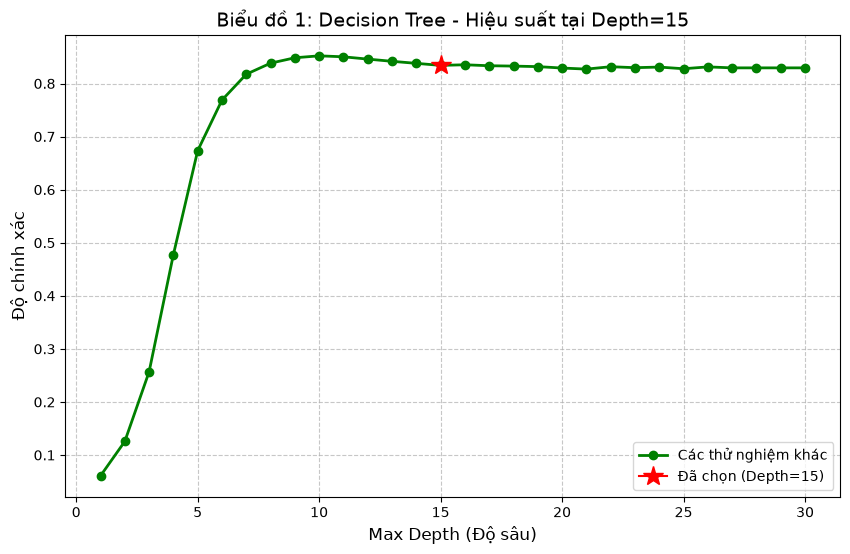


🌲 Đang chạy Random Forest...
👉 Đã chọn N = 400. Độ chính xác: 87.17%


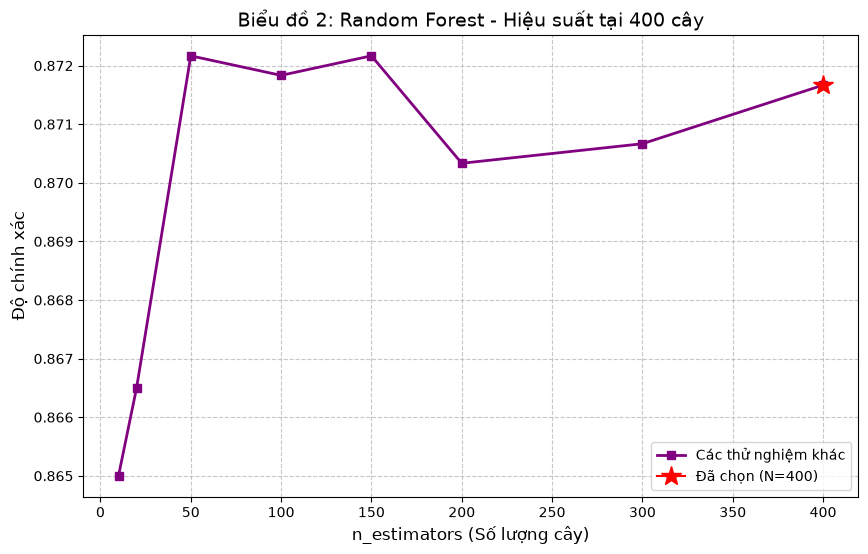


✅ TỔNG HỢP KẾT QUẢ THAM SỐ ĐÃ CHỌN:
1. Decision Tree (Depth=15): Độ chính xác = 83.42%
2. Random Forest (N=400):       Độ chính xác = 87.17%



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Load dữ liệu
try:
    df = pd.read_csv('Du_lieu_mau.csv')
    print("✅ Đã tải dữ liệu thành công!")
except FileNotFoundError:
    print("❌ LỖI: Không tìm thấy file. Hãy kiểm tra lại.")
    df = pd.DataFrame() # Tạo rỗng để tránh crash

if not df.empty:
    # 2. Chuẩn bị dữ liệu
    feature_names = ['mass', 'width', 'height', 'color_score']
    X = df[feature_names]
    y = df['fruit_label']

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    # ==============================================================================
    # BIỂU ĐỒ 1: DECISION TREE (CHỌN DEPTH = 15)
    # ==============================================================================
    print("\n🌳 Đang chạy Decision Tree...")
    dt_depths = range(1, 31)
    dt_scores = []

    for d in dt_depths:
        dt = DecisionTreeClassifier(max_depth=d, criterion='entropy', random_state=42)
        dt.fit(X_train, y_train)
        dt_scores.append(dt.score(X_test, y_test))

    # --- PHẦN BẠN CHỌN: DEPTH = 15 ---
    chosen_depth = 15
    if chosen_depth in dt_depths:
        chosen_acc_dt = dt_scores[list(dt_depths).index(chosen_depth)]
        print(f"👉 Đã chọn Depth = {chosen_depth}. Độ chính xác: {chosen_acc_dt*100:.2f}%")
    else:
        chosen_acc_dt = 0
        print(f"⚠️ Depth {chosen_depth} không nằm trong phạm vi thử nghiệm.")

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    plt.plot(dt_depths, dt_scores, marker='o', linestyle='-', color='green', linewidth=2, label='Các thử nghiệm khác')
    
    # Đánh dấu điểm đã chọn (Ngôi sao màu đỏ)
    plt.plot(chosen_depth, chosen_acc_dt, marker='*', color='red', markersize=15, label=f'Đã chọn (Depth={chosen_depth})')
    
    plt.title(f'Biểu đồ 1: Decision Tree - Hiệu suất tại Depth={chosen_depth}', fontsize=14)
    plt.xlabel('Max Depth (Độ sâu)', fontsize=12)
    plt.ylabel('Độ chính xác', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend() # Hiện chú thích
    plt.show()

    # ==============================================================================
    # BIỂU ĐỒ 2: RANDOM FOREST (CHỌN 400 CÂY)
    # ==============================================================================
    print("\n🌲 Đang chạy Random Forest...")
    rf_estimators = [10, 20, 50, 100, 150, 200, 300, 400]
    rf_scores = []

    for n in rf_estimators:
        rf = RandomForestClassifier(n_estimators=n, criterion='entropy', random_state=42)
        rf.fit(X_train, y_train)
        rf_scores.append(rf.score(X_test, y_test))

    # --- PHẦN BẠN CHỌN: 400 CÂY ---
    chosen_n = 400
    if chosen_n in rf_estimators:
        chosen_acc_rf = rf_scores[rf_estimators.index(chosen_n)]
        print(f"👉 Đã chọn N = {chosen_n}. Độ chính xác: {chosen_acc_rf*100:.2f}%")
    else:
        chosen_acc_rf = 0
        print(f"⚠️ N = {chosen_n} không nằm trong danh sách thử nghiệm.")

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    plt.plot(rf_estimators, rf_scores, marker='s', linestyle='-', color='purple', linewidth=2, label='Các thử nghiệm khác')
    
    # Đánh dấu điểm đã chọn (Ngôi sao màu đỏ)
    plt.plot(chosen_n, chosen_acc_rf, marker='*', color='red', markersize=15, label=f'Đã chọn (N={chosen_n})')
    
    plt.title(f'Biểu đồ 2: Random Forest - Hiệu suất tại {chosen_n} cây', fontsize=14)
    plt.xlabel('n_estimators (Số lượng cây)', fontsize=12)
    plt.ylabel('Độ chính xác', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend() # Hiện chú thích
    plt.show()

    # ==============================================================================
    # 3. TỔNG KẾT
    # ==============================================================================
    print("\n" + "="*40)
    print("✅ TỔNG HỢP KẾT QUẢ THAM SỐ ĐÃ CHỌN:")
    print(f"1. Decision Tree (Depth={chosen_depth}): Độ chính xác = {chosen_acc_dt*100:.2f}%")
    print(f"2. Random Forest (N={chosen_n}):       Độ chính xác = {chosen_acc_rf*100:.2f}%")
    print("="*40 + "\n")

Đang tìm K tối ưu...
------------------------------
🏆 K TỐT NHẤT LÀ: 17
✅ Độ chính xác: 84.02%
------------------------------


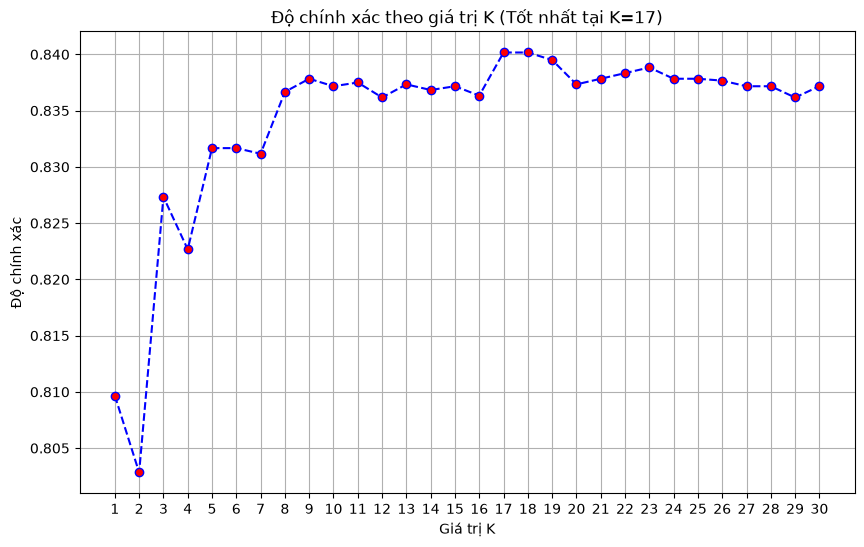

In [4]:
fruit = pd.read_csv('Du_lieu_mau.csv')
# 1. Chuẩn bị dữ liệu (Quan trọng: Phải chuẩn hóa!)
X = fruit[['mass', 'width', 'height', 'color_score']]
y = fruit['fruit_label']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 2. Chạy vòng lặp tìm K tốt nhất (từ 1 đến 30)
k_range = range(1, 31)
scores = []

print("Đang tìm K tối ưu...")
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

# 3. In kết quả
best_k = k_range[np.argmax(scores)]
best_acc = max(scores)

print("-" * 30)
print(f"🏆 K TỐT NHẤT LÀ: {best_k}")
print(f"✅ Độ chính xác: {best_acc*100:.2f}%")
print("-" * 30)

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker='o', linestyle='dashed', color='b', markerfacecolor='red')
plt.title(f'Độ chính xác theo giá trị K (Tốt nhất tại K={best_k})')
plt.xlabel('Giá trị K')
plt.ylabel('Độ chính xác')
plt.xticks(k_range)
plt.grid(True)
plt.show()

D:\H_Nguyen\Dai_Hoc_Cong_Thuong_TPHCM\Nam_3\Hoc_Ky_5\Trí tuệ nhân tạo - Lý thuyết\Thuyết trình kết thúc đề tài\fruit-data-with-colours-master\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between 'x' with shape (4,) and 'height' with shape (30,).

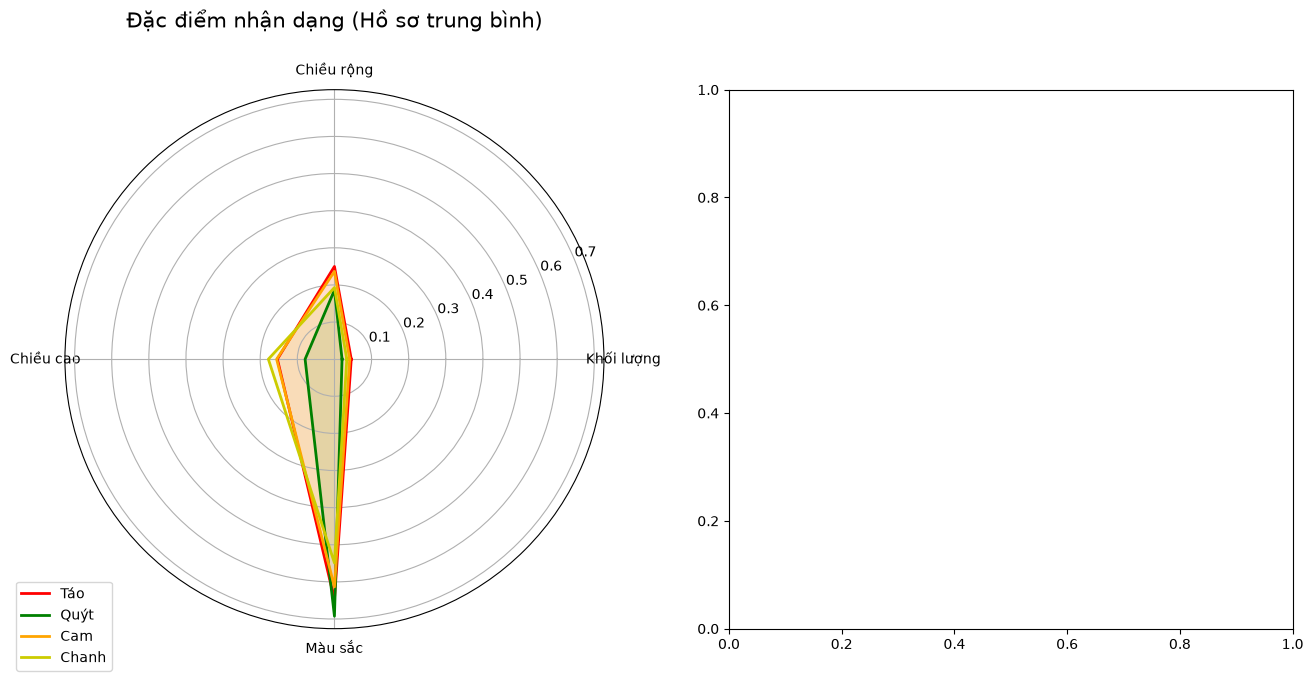

In [5]:
# 1. Lấy dữ liệu mẫu "Chuẩn" (Trung bình cộng của từng loại)
# Để đại diện cho Táo, Quýt, Cam, Chanh điển hình
means = fruits.groupby('fruit_label')[['mass', 'width', 'height', 'color_score']].mean()
data_samples = means.values # Lấy giá trị số
labels = ['Táo', 'Quýt', 'Cam', 'Chanh']
colors = ['red', 'green', 'orange', '#CCCC00'] # Màu tương ứng (Vàng chanh hơi đậm chút cho dễ nhìn)

# 2. Dự đoán thử (Xem model soi xét 4 quả này thế nào)
probs = ensemble_model.predict_proba(data_samples)

# 3. Vẽ biểu đồ
fig = plt.figure(figsize=(16, 7))

# --- PLOT 1: RADAR CHART (INPUT) ---
ax1 = fig.add_subplot(121, polar=True)
categories = ['Khối lượng', 'Chiều rộng', 'Chiều cao', 'Màu sắc']
N = len(categories)

# Góc chia biểu đồ
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Chuẩn hóa dữ liệu về 0-1 để vẽ đè lên nhau được
scaler = MinMaxScaler()
scaler.fit(fruits[['mass', 'width', 'height', 'color_score']]) # Fit trên toàn bộ dữ liệu gốc
scaled_samples = scaler.transform(data_samples)

# Vẽ từng loại quả
for i in range(4):
    values = scaled_samples[i].tolist()
    values += values[:1]
    ax1.plot(angles, values, linewidth=2, linestyle='solid', label=labels[i], color=colors[i])
    ax1.fill(angles, values, color=colors[i], alpha=0.1)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)
ax1.set_title('Đặc điểm nhận dạng (Hồ sơ trung bình)', size=15, y=1.1)
ax1.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# --- PLOT 2: BAR CHART (OUTPUT) ---
ax2 = fig.add_subplot(122)
fruit_classes = ['Táo', 'Quýt', 'Cam', 'Chanh']
x = np.arange(len(fruit_classes))
width = 0.2

# Vẽ 4 nhóm cột
for i in range(4):
    # Dịch chuyển vị trí cột để không đè nhau
    position = x + (i - 1.5) * width
    rects = ax2.bar(position, probs[i], width, label=f'Input là {labels[i]}', color=colors[i], alpha=0.8, edgecolor='black')
    
    # Hiện số % lên đầu cột nào cao nhất
    for rect in rects:
        height = rect.get_height()
        if height > 0.8: # Chỉ hiện số ở cột đúng
            ax2.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontweight='bold')

ax2.set_ylabel('Độ tin cậy')
ax2.set_title('Kết quả nhận diện của Model', size=15)
ax2.set_xticks(x)
ax2.set_xticklabels(fruit_classes)
ax2.legend()

plt.tight_layout()
plt.show()